# Explore Player Match Data

Notebook này dùng để kiểm tra dữ liệu đã clean và join đúng chưa, trước khi train model.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
df = pd.read_csv('../data/processed/player_match_dataset_cleaned.csv', low_memory=False)
df['match_date'] = pd.to_datetime(df['match_date'], errors='coerce')
df['year'] = df['match_date'].dt.year

df.head()

,player_name,player_id,team,team_id,opponent_team,opponent_team_id,agent,map,match_id,event_id,...,team_avg_rating,team_avg_acs,team_avg_kda,opp_avg_rating,opp_avg_acs,opp_avg_kda,opp_rating_gap,opp_acs_gap,opp_kda_gap,year
0,yetujey,8369,FUT,1184.0,Natus Vincere,4915.0,viper,Split,712803,2976,...,1.007356,201.928105,1.539126,0.992689,196.803404,1.4663,0.014667,5.1247,0.072826,2026
1,xeus,12793,FUT,1184.0,Natus Vincere,4915.0,raze,Split,712803,2976,...,1.007356,201.928105,1.539126,0.992689,196.803404,1.4663,0.014667,5.1247,0.072826,2026
2,KROSTALY,15735,FUT,1184.0,Natus Vincere,4915.0,skye,Split,712803,2976,...,1.007356,201.928105,1.539126,0.992689,196.803404,1.4663,0.014667,5.1247,0.072826,2026
3,sociablEE,5568,FUT,1184.0,Natus Vincere,4915.0,omen,Split,712803,2976,...,1.007356,201.928105,1.539126,0.992689,196.803404,1.4663,0.014667,5.1247,0.072826,2026
4,s0pp,39357,FUT,1184.0,Natus Vincere,4915.0,jett,Split,712803,2976,...,1.007356,201.928105,1.539126,0.992689,196.803404,1.4663,0.014667,5.1247,0.072826,2026


In [14]:
print(df.shape)
print(df.dtypes.head(20).to_string())
print(df.isna().sum().sort_values(ascending=False).head(20))

(73135, 63)
player_name                             str
player_id                             int64
team                                    str
team_id                             float64
opponent_team                           str
opponent_team_id                    float64
agent                                   str
map                                     str
match_id                              int64
event_id                              int64
match_date                   datetime64[us]
match_time                              str
team_1                                  str
team_2                                  str
team_pick                               str
map_winner                              str
first_half_ct_win_rounds              int64
first_half_t_win_rounds               int64
second_half_ct_win_rounds             int64
second_half_t_win_rounds              int64
hsp_t                       978
hsp_ct                      912
adr_ct                      858
kast_t      

In [15]:
numeric_cols = [
    'rating2_all', 'acs_all', 'kills_all', 'deaths_all', 'assists_all', 'kast_all', 'adr_all', 'hsp_all', 'fb_all', 'fd_all'
]
df[numeric_cols].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
rating2_all,73135.0,0.991035,0.371351,0.01,0.74,0.97,1.22,2.88
acs_all,73135.0,200.712340,64.408068,4.00,156.00,196.00,240.00,567.00
kills_all,73135.0,14.342736,5.625799,0.00,10.00,14.00,18.00,47.00
deaths_all,73135.0,14.325344,4.049271,0.00,12.00,15.00,17.00,41.00
assists_all,73135.0,5.233855,3.282031,0.00,3.00,5.00,7.00,29.00
kast_all,73133.0,0.701761,0.138755,0.07,0.62,0.71,0.80,1.00
adr_all,73135.0,129.173200,39.380221,3.00,102.00,127.00,154.00,354.00
hsp_all,73135.0,0.261830,0.096970,0.00,0.19,0.25,0.32,1.00
fb_all,73135.0,2.036631,1.765527,0.00,1.00,2.00,3.00,14.00
fd_all,73135.0,2.032871,1.635599,0.00,1.00,2.00,3.00,15.00


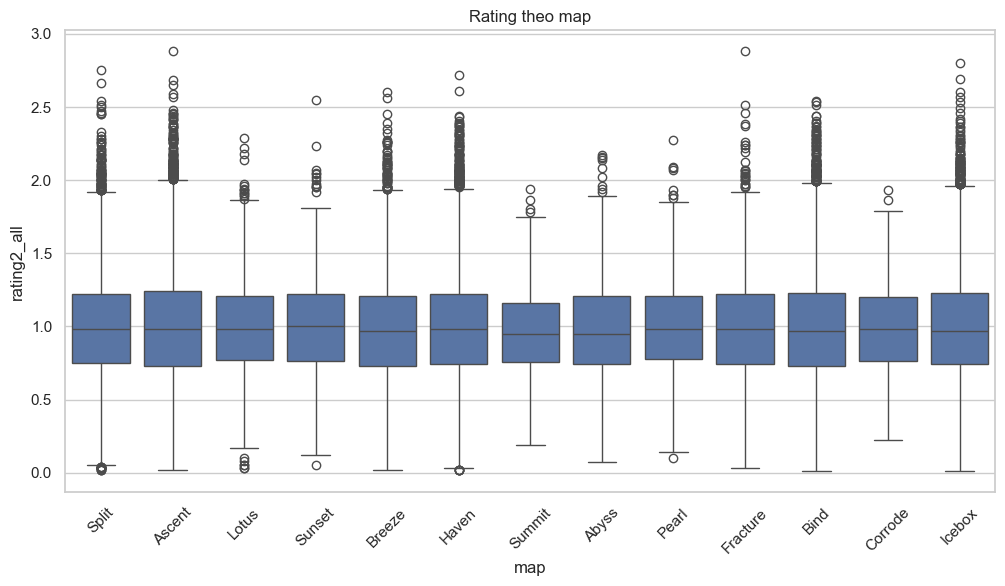

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='map', y='rating2_all')
plt.xticks(rotation=45)
plt.title('Rating theo map')
plt.show()

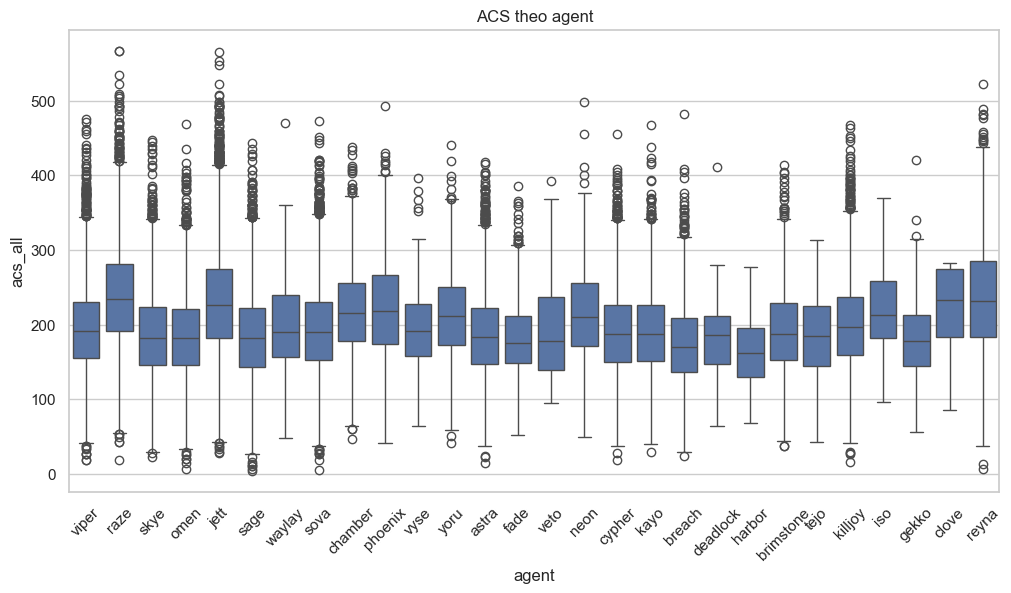

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='agent', y='acs_all')
plt.xticks(rotation=45)
plt.title('ACS theo agent')
plt.show()

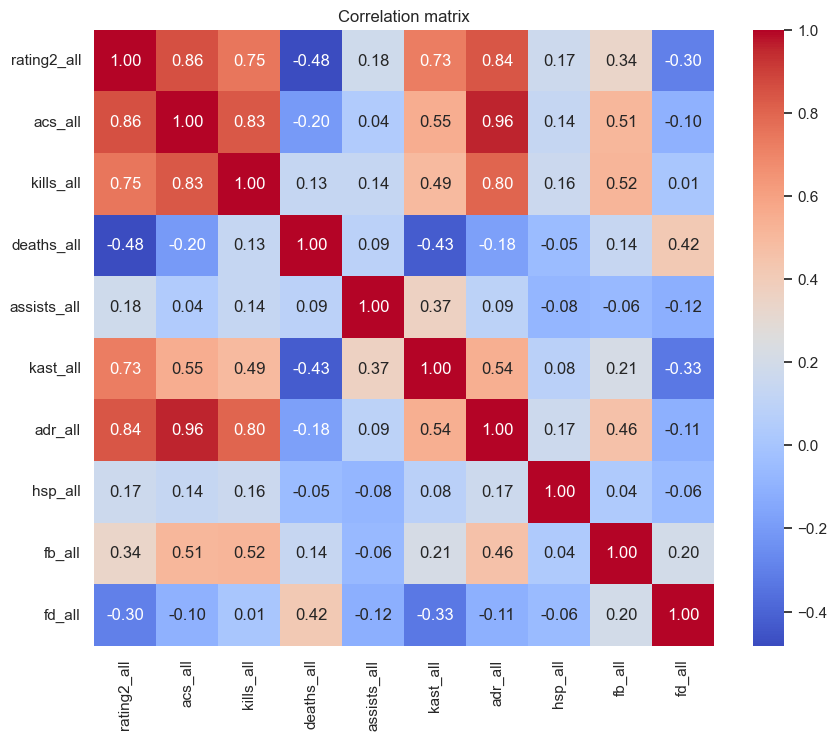

In [18]:
corr = df[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

In [19]:
# 1) Số đội tuyển và số player
n_teams = df['team_id'].nunique()
n_players = df['player_id'].nunique()
print(f'Số đội tuyển: {n_teams}')
print(f'Số player: {n_players}')

# Một số team / player nổi bật
print('\nTop 10 đội nhiều bản ghi nhất:')
print(df['team'].value_counts().head(10).to_string())
print('\nTop 10 player nhiều bản ghi nhất:')
print(df.groupby('player_id')['match_id'].nunique().sort_values(ascending=False).head(10).to_string())

Số đội tuyển: 1382
Số player: 5628

Top 10 đội nhiều bản ghi nhất:
team
TL      2050
FNC     1940
VIT     1415
TH      1365
FUT     1320
BBL     1310
NAVI    1175
G2      1100
KC       880
Team     839

Top 10 player nhiều bản ghi nhất:
player_id
458     153
438     152
9780    149
457     147
5022    146
9810    132
1144    131
2858    125
384     117
4181    112


Player chơi trong 2-3 năm: 1281

Phân bố số năm chơi:
years_played
1    4274
2    1207
3      74
4      41
5      18
6      14


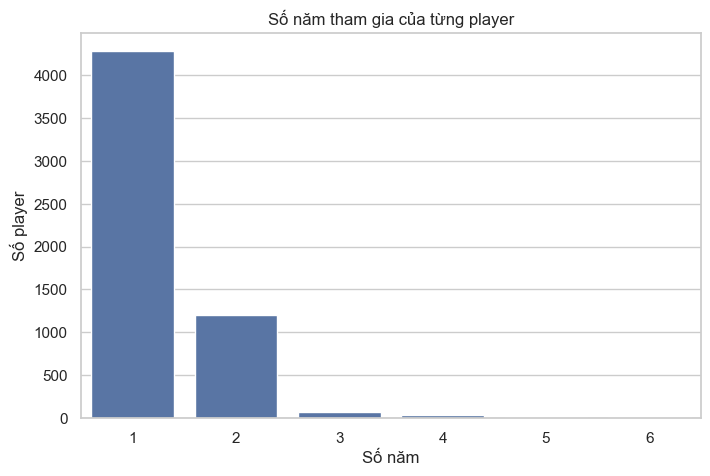

In [20]:
# 2) Có bao nhiêu player chơi trong 2-3 năm?
player_years = (
    df.dropna(subset=['match_date'])
      .groupby('player_id')['year']
      .nunique()
      .reset_index(name='years_played')
)
count_2_3_years = ((player_years['years_played'] >= 2) & (player_years['years_played'] <= 3)).sum()
print(f'Player chơi trong 2-3 năm: {count_2_3_years}')
print('\nPhân bố số năm chơi:')
print(player_years['years_played'].value_counts().sort_index().to_string())

# Biểu đồ phân bố
plt.figure(figsize=(8, 5))
sns.countplot(data=player_years, x='years_played')
plt.title('Số năm tham gia của từng player')
plt.xlabel('Số năm')
plt.ylabel('Số player')
plt.show()

In [21]:
# 3) Thống kê cơ bản của các chỉ số player
stat_cols = [
    'rating2_all', 'acs_all', 'kills_all', 'deaths_all', 'assists_all',
    'kast_all', 'adr_all', 'hsp_all', 'fb_all', 'fd_all', 'kda_all'
]
summary = df[stat_cols].describe().T.round(2)
print(summary)

# Chỉ ra các stat có phân bố lệch nghiêng nhất
summary['std'] = df[stat_cols].std(ddof=1)
summary['mean'] = df[stat_cols].mean()
summary[['mean', 'std', 'min', '50%', 'max']].sort_values('std', ascending=False)

               count    mean    std   min     25%     50%     75%     max
rating2_all  73135.0    0.99   0.37  0.01    0.74    0.97    1.22    2.88
acs_all      73135.0  200.71  64.41  4.00  156.00  196.00  240.00  567.00
kills_all    73135.0   14.34   5.63  0.00   10.00   14.00   18.00   47.00
deaths_all   73135.0   14.33   4.05  0.00   12.00   15.00   17.00   41.00
assists_all  73135.0    5.23   3.28  0.00    3.00    5.00    7.00   29.00
kast_all     73133.0    0.70   0.14  0.07    0.62    0.71    0.80    1.00
adr_all      73135.0  129.17  39.38  3.00  102.00  127.00  154.00  354.00
hsp_all      73135.0    0.26   0.10  0.00    0.19    0.25    0.32    1.00
fb_all       73135.0    2.04   1.77  0.00    1.00    2.00    3.00   14.00
fd_all       73135.0    2.03   1.64  0.00    1.00    2.00    3.00   15.00
kda_all      73123.0    1.54   0.98  0.00    1.00    1.33    1.83   29.00


,mean,std,min,50%,max
acs_all,200.712340,64.408068,4.00,196.00,567.00
adr_all,129.173200,39.380221,3.00,127.00,354.00
kills_all,14.342736,5.625799,0.00,14.00,47.00
deaths_all,14.325344,4.049271,0.00,15.00,41.00
assists_all,5.233855,3.282031,0.00,5.00,29.00
fb_all,2.036631,1.765527,0.00,2.00,14.00
fd_all,2.032871,1.635599,0.00,2.00,15.00
kda_all,1.535408,0.984774,0.00,1.33,29.00
rating2_all,0.991035,0.371351,0.01,0.97,2.88
kast_all,0.701761,0.138755,0.07,0.71,1.00


Top 10 map:
map
Ascent      15523
Haven       12239
Bind        11890
Icebox      11044
Split        9639
Breeze       5160
Lotus        2310
Fracture     2240
Sunset       1100
Pearl         810

Top 10 agent:
agent
sova       9503
jett       8975
viper      5932
sage       5749
omen       5272
killjoy    5054
raze       4812
astra      4792
cypher     4667
skye       4064

Rating trung bình theo map:
map
Pearl       0.998617
Lotus       0.997654
Sunset      0.997500
Fracture    0.995482
Corrode     0.995048
Ascent      0.994138
Split       0.991129
Icebox      0.990256
Bind        0.990086
Haven       0.988796


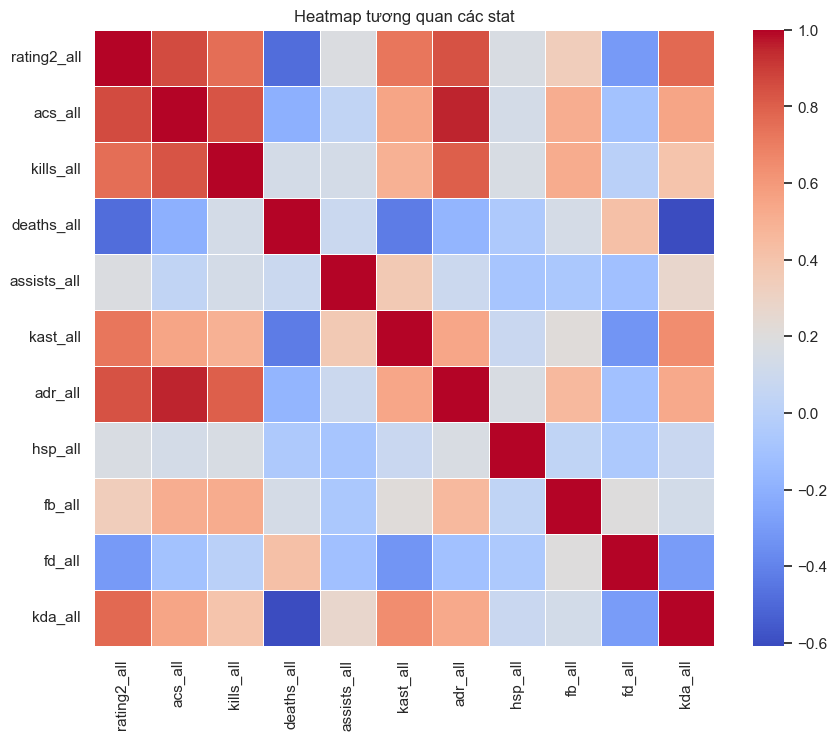

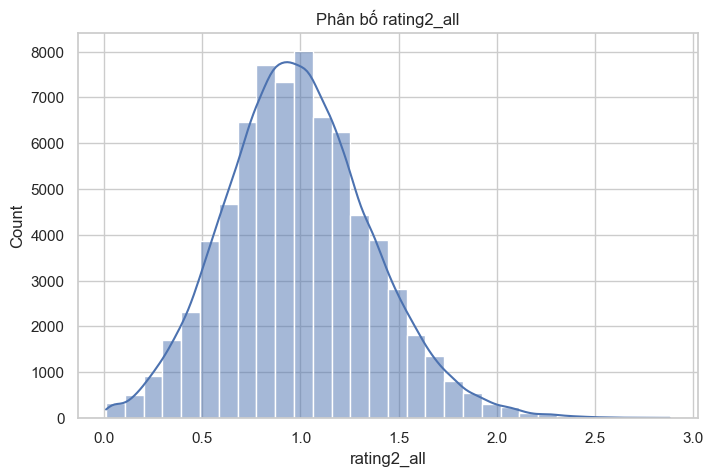

In [22]:
# 4) Khám phá thêm theo map, agent, và tương quan
# Top map
print('Top 10 map:')
print(df['map'].value_counts().head(10).to_string())

# Top agent
print('\nTop 10 agent:')
print(df['agent'].value_counts().head(10).to_string())

# Rating trung bình theo map
map_rating = df.groupby('map')['rating2_all'].mean().sort_values(ascending=False)
print('\nRating trung bình theo map:')
print(map_rating.head(10).to_string())

# Heatmap tương quan giữa các stat cơ bản
corr = df[stat_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap tương quan các stat')
plt.show()

# Plot phân bố rating2_all
plt.figure(figsize=(8, 5))
sns.histplot(df['rating2_all'], bins=30, kde=True)
plt.title('Phân bố rating2_all')
plt.xlabel('rating2_all')
plt.show()

## Consolidated exploratory data analysis

This section combines basic data inspection, univariate analysis, bivariate analysis, multivariate analysis, and missing-value analysis for the cleaned player-match dataset.

Dataset shape: (73135, 62)
Duplicate rows: 30


,player_name,player_id,team,team_id,opponent_team,opponent_team_id,agent,map,match_id,event_id,...,kda_all,team_avg_rating,team_avg_acs,team_avg_kda,opp_avg_rating,opp_avg_acs,opp_avg_kda,opp_rating_gap,opp_acs_gap,opp_kda_gap
0,yetujey,8369,FUT,1184.0,Natus Vincere,4915.0,viper,Split,712803,2976,...,1.200000,1.007356,201.928105,1.539126,0.992689,196.803404,1.4663,0.014667,5.1247,0.072826
1,xeus,12793,FUT,1184.0,Natus Vincere,4915.0,raze,Split,712803,2976,...,0.933333,1.007356,201.928105,1.539126,0.992689,196.803404,1.4663,0.014667,5.1247,0.072826
2,KROSTALY,15735,FUT,1184.0,Natus Vincere,4915.0,skye,Split,712803,2976,...,1.153846,1.007356,201.928105,1.539126,0.992689,196.803404,1.4663,0.014667,5.1247,0.072826
3,sociablEE,5568,FUT,1184.0,Natus Vincere,4915.0,omen,Split,712803,2976,...,1.000000,1.007356,201.928105,1.539126,0.992689,196.803404,1.4663,0.014667,5.1247,0.072826
4,s0pp,39357,FUT,1184.0,Natus Vincere,4915.0,jett,Split,712803,2976,...,0.647059,1.007356,201.928105,1.539126,0.992689,196.803404,1.4663,0.014667,5.1247,0.072826


,dtype
player_name,str
player_id,int64
team,str
team_id,float64
opponent_team,str
...,...
opp_avg_acs,float64
opp_avg_kda,float64
opp_rating_gap,float64
opp_acs_gap,float64


,missing_count,missing_percent
hsp_t,978,1.337253
hsp_ct,912,1.247009
adr_ct,858,1.173173
kast_t,581,0.794421
kast_ct,558,0.762973
acs_ct,379,0.518220
kda_all,12,0.016408
team,10,0.013673
acs_t,3,0.004102
kast_all,2,0.002735


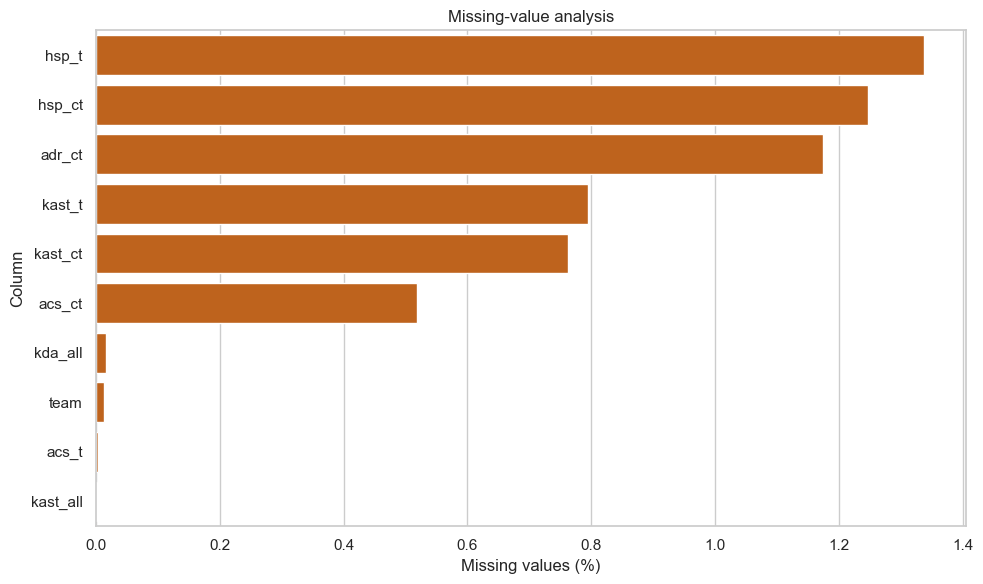

,count,mean,std,min,25%,50%,75%,max
player_id,73135.0,8.162564e+03,7897.405328,4.000000,1828.000000,5660.000000,12611.000000,58959.000000
team_id,73135.0,4.231237e+03,3142.360084,2.000000,1594.000000,4096.000000,6110.000000,20085.000000
opponent_team_id,73135.0,4.232192e+03,3144.449185,2.000000,1594.000000,4097.000000,6129.000000,20085.000000
match_id,73135.0,1.227599e+05,186330.713541,10776.000000,23796.000000,51270.000000,65310.000000,731408.000000
event_id,73135.0,9.296298e+02,714.912814,320.000000,541.000000,664.000000,797.000000,2976.000000
first_half_ct_win_rounds,73135.0,5.986436e+00,2.774958,0.000000,4.000000,6.000000,8.000000,12.000000
first_half_t_win_rounds,73135.0,5.962426e+00,2.777938,0.000000,4.000000,6.000000,8.000000,12.000000
second_half_ct_win_rounds,73135.0,3.939099e+00,2.398196,0.000000,2.000000,4.000000,6.000000,11.000000
second_half_t_win_rounds,73135.0,4.002994e+00,2.434170,0.000000,2.000000,4.000000,6.000000,11.000000
ot_team_ct_win,73135.0,1.989198e-01,0.824795,0.000000,0.000000,0.000000,0.000000,11.000000


,unique_values,most_common
player_name,5572,Chronicle
team,1213,TL
opponent_team,1365,Team Liquid
agent,28,sova
map,13,Ascent
match_date,562,2021-06-29 00:00:00
match_time,102,12:00 AM
team_1,886,FNATIC
team_2,1072,Team Liquid
team_pick,162,Decider


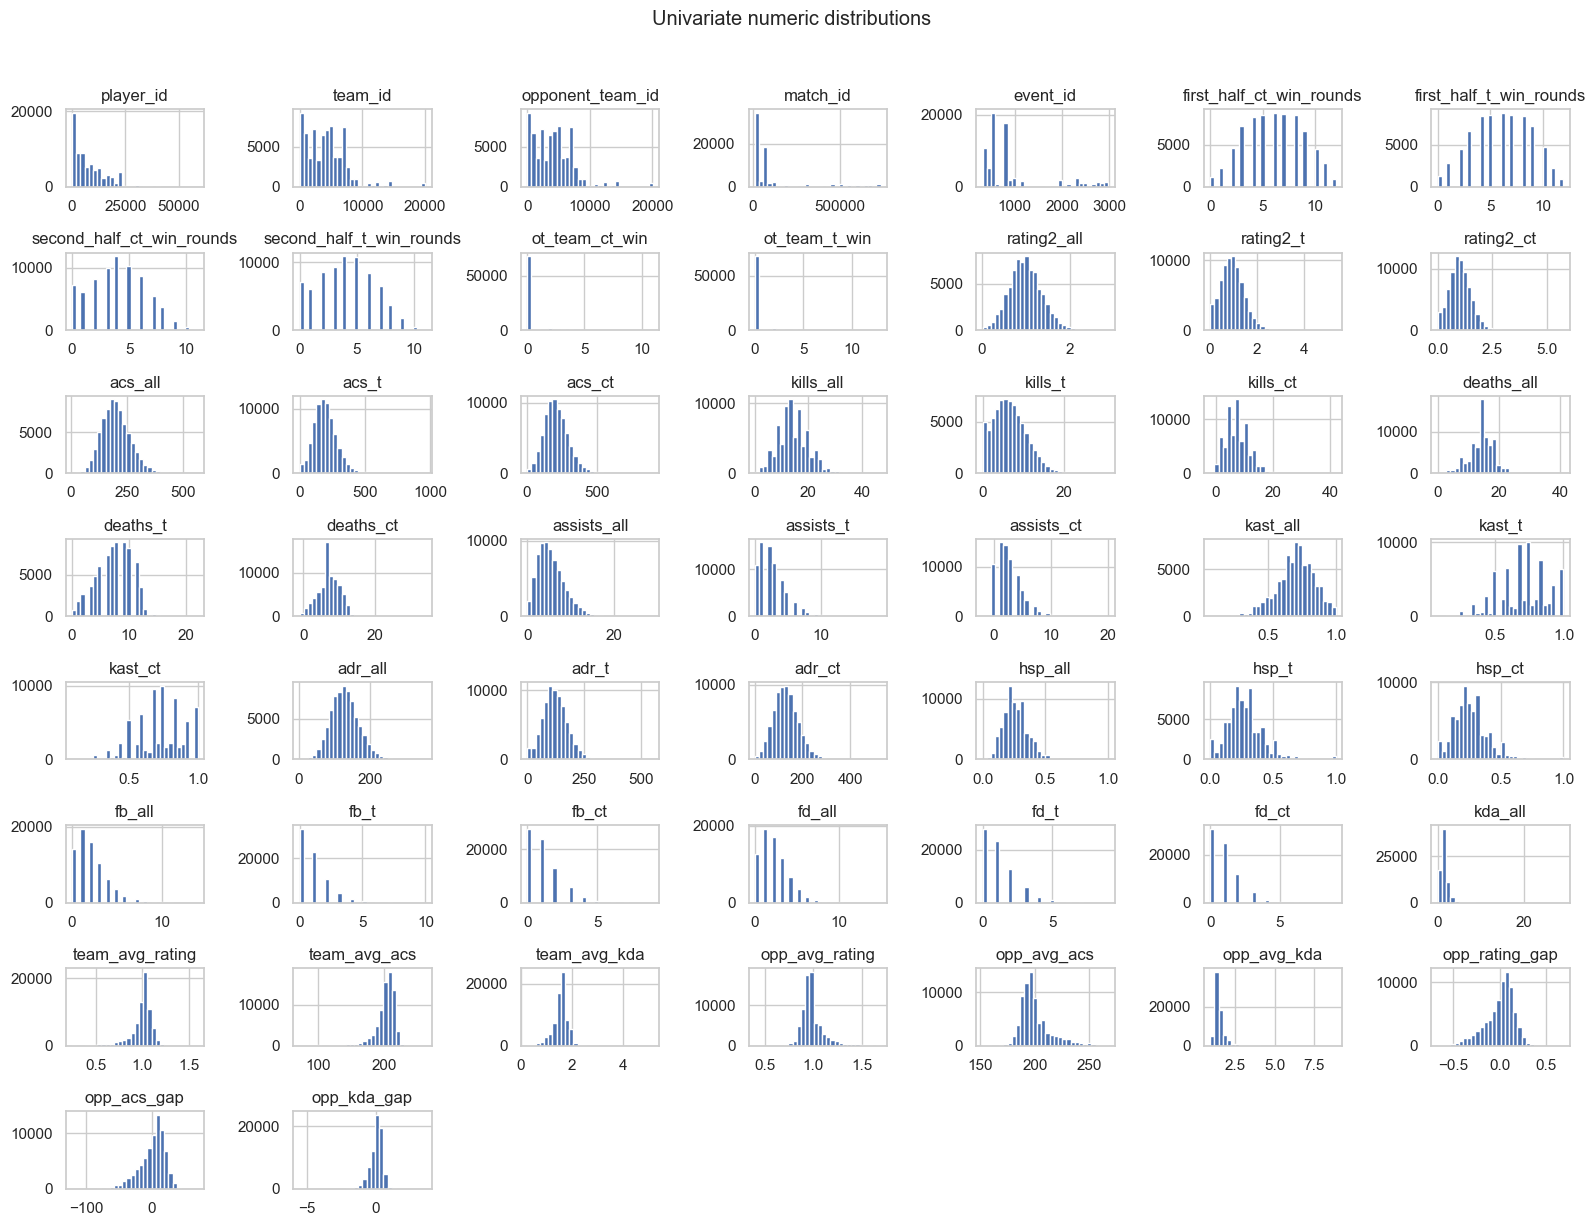

,correlation_with_rating2_all
acs_all,0.860285
adr_all,0.840785
kda_all,0.769137
kills_all,0.750406
rating2_t,0.737159
rating2_ct,0.735675
kast_all,0.726938
acs_ct,0.619146
acs_t,0.616829
adr_ct,0.597453


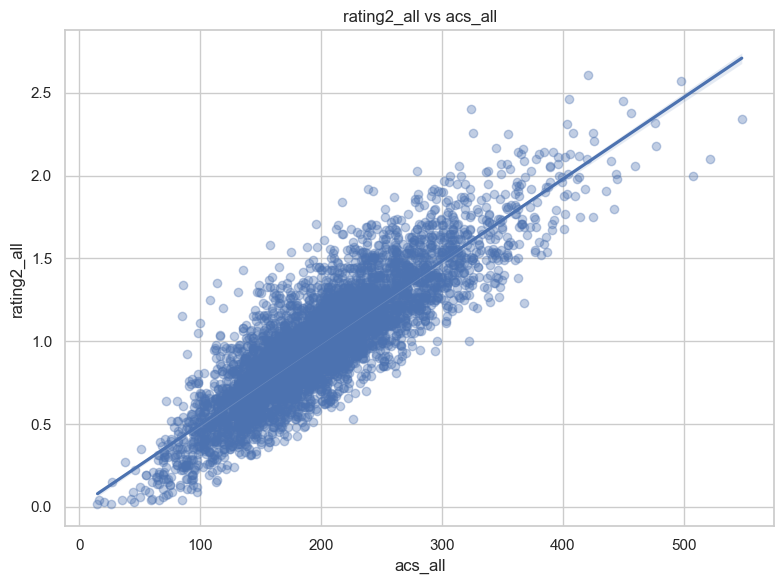

,count,mean,median
agent,,,
chamber,1181,1.062286,1.05
raze,4812,1.056241,1.04
iso,64,1.049844,1.00
reyna,1973,1.048312,1.03
jett,8975,1.036936,1.01
phoenix,903,1.034175,1.02
sova,9503,1.018200,1.00
vyse,323,1.003901,0.97
yoru,795,1.000000,0.99


,count,mean,median
map,,,
Pearl,810,0.998617,0.98
Lotus,2310,0.997654,0.98
Sunset,1100,0.997500,1.00
Fracture,2240,0.995482,0.98
Corrode,420,0.995048,0.98
Ascent,15523,0.994138,0.98
Split,9639,0.991129,0.98
Icebox,11044,0.990256,0.97
Bind,11890,0.990086,0.97


,count,mean,median
team,,,
Ovat,10,1.532000,1.725
300S,10,1.349000,1.380
Say,15,1.258000,1.180
TQM,5,1.254000,1.280
5up,20,1.242000,1.225
ooli,20,1.233500,1.290
KVT,5,1.218000,1.040
SUPR,25,1.214000,1.150
HONK,55,1.213273,1.200


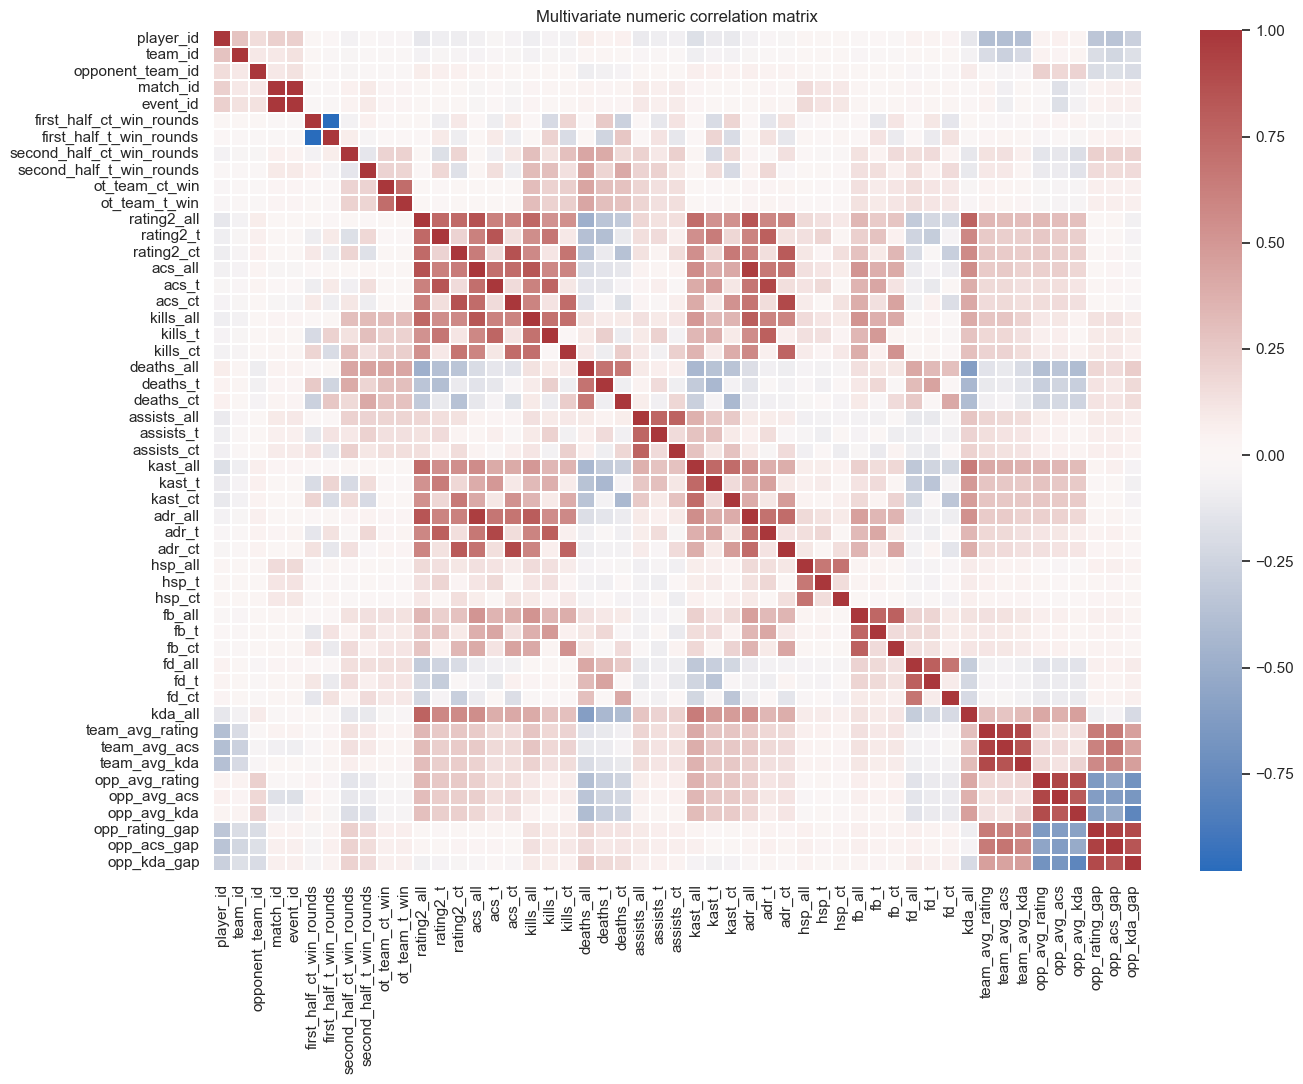

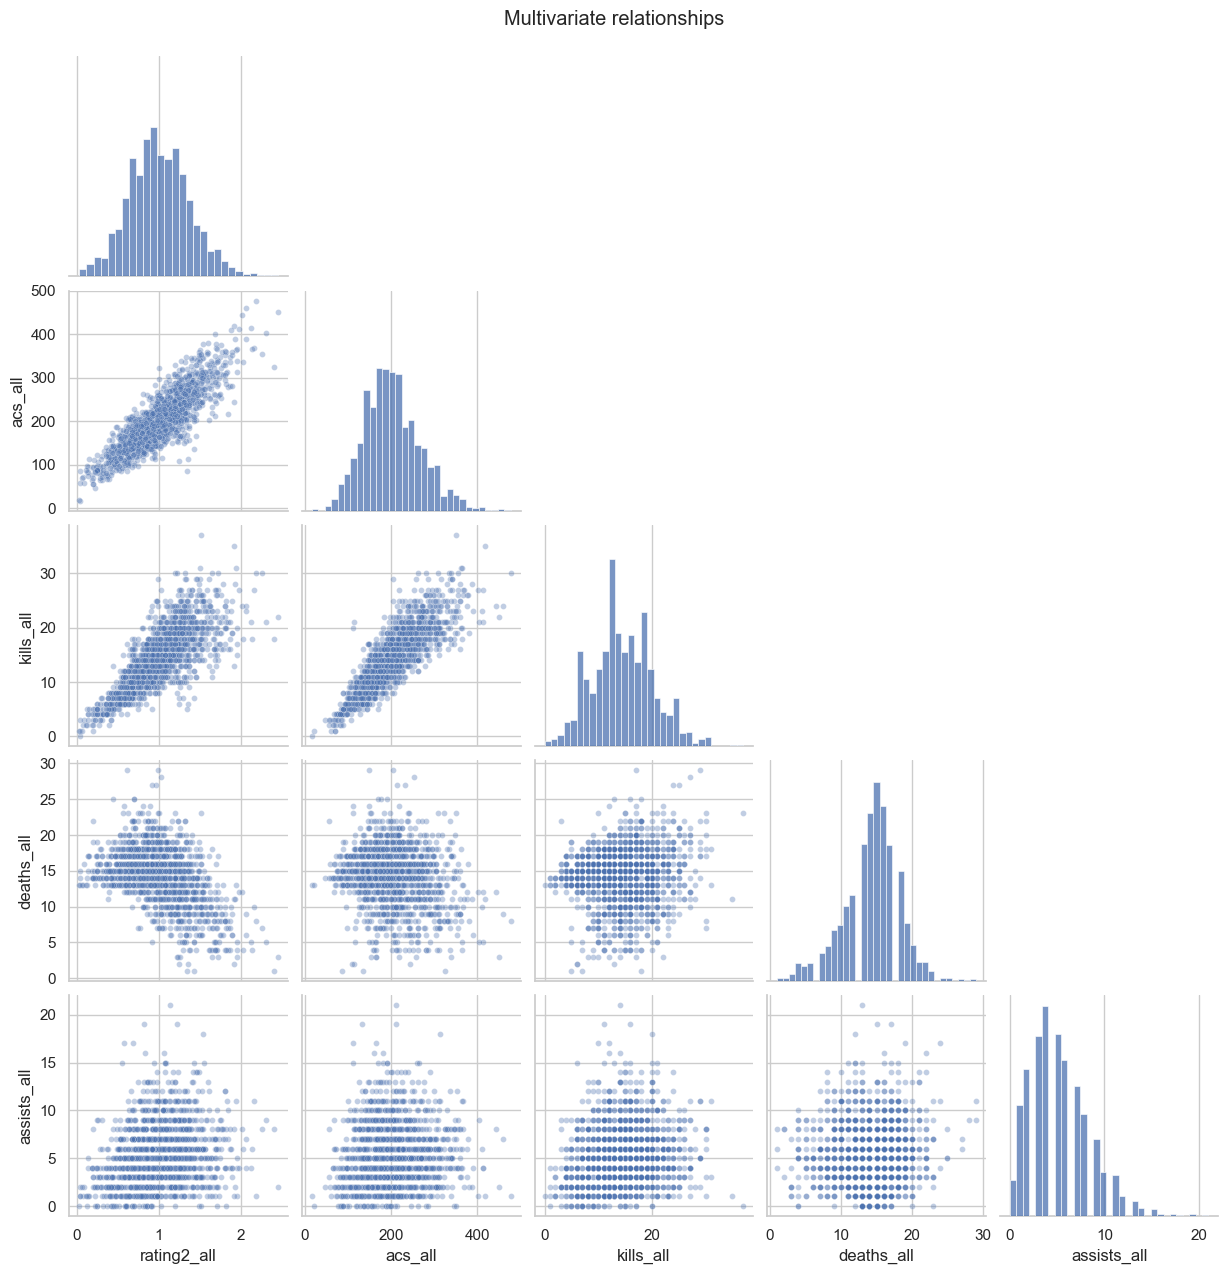

Analysis complete. Outputs saved to: D:\US\Projects\VCTProject\reports\eda


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

ROOT = Path("..")
INPUT_PATH = ROOT / "data/processed/player_match_dataset_cleaned.csv"
EDA_OUTPUT = ROOT / "reports/eda"
EDA_OUTPUT.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(INPUT_PATH, low_memory=False)
df["match_date"] = pd.to_datetime(df["match_date"], errors="coerce")

print(f"Dataset shape: {df.shape}")
print(f"Duplicate rows: {df.duplicated().sum()}")
display(df.head())
display(df.dtypes.rename("dtype").to_frame())
df.describe(include="all").T.to_csv(EDA_OUTPUT / "descriptive_statistics.csv")
df.dtypes.rename("dtype").to_frame().to_csv(EDA_OUTPUT / "data_types.csv")

# Missing-value analysis
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100),
}).sort_values("missing_percent", ascending=False)
display(missing.head(20))
missing.to_csv(EDA_OUTPUT / "missing_values.csv")
nonzero_missing = missing[missing["missing_count"] > 0]
if not nonzero_missing.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=nonzero_missing.reset_index(), x="missing_percent", y="index", color="#d95f02")
    plt.title("Missing-value analysis")
    plt.xlabel("Missing values (%)")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.savefig(EDA_OUTPUT / "missing_values.png", dpi=150)
    plt.show()
    plt.close()

# Univariate analysis
numeric = df.select_dtypes(include="number")
categorical = df.select_dtypes(exclude="number")
display(numeric.describe().T)
categorical_summary = pd.DataFrame({
    "unique_values": categorical.nunique(dropna=False),
    "most_common": categorical.mode(dropna=False).iloc[0],
})
display(categorical_summary)
numeric.describe().T.to_csv(EDA_OUTPUT / "numeric_summary.csv")
categorical_summary.to_csv(EDA_OUTPUT / "categorical_summary.csv")

numeric.hist(figsize=(16, 12), bins=30, edgecolor="white")
plt.suptitle("Univariate numeric distributions", y=1.02)
plt.tight_layout()
plt.savefig(EDA_OUTPUT / "numeric_distributions.png", dpi=150)
plt.show()
plt.close()

# Bivariate analysis
TARGET = "rating2_all"
correlations = numeric.corr()
correlations.to_csv(EDA_OUTPUT / "numeric_correlations.csv")
if TARGET in numeric.columns:
    target_correlations = correlations[TARGET].drop(TARGET).sort_values(
        key=lambda values: values.abs(), ascending=False
    )
    display(target_correlations.to_frame("correlation_with_rating2_all"))
    target_correlations.rename("correlation_with_rating2_all").to_csv(
        EDA_OUTPUT / "target_correlations.csv"
    )
    strongest = target_correlations.index[0]
    sample = df[[strongest, TARGET]].dropna()
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)
    plt.figure(figsize=(8, 6))
    sns.regplot(data=sample, x=strongest, y=TARGET, scatter_kws={"alpha": 0.35})
    plt.title(f"{TARGET} vs {strongest}")
    plt.tight_layout()
    plt.savefig(EDA_OUTPUT / "target_vs_strongest_feature.png", dpi=150)
    plt.show()
    plt.close()

for category in ["agent", "map", "team"]:
    if category in df.columns and TARGET in df.columns:
        grouped = df.groupby(category, dropna=False)[TARGET].agg(["count", "mean", "median"])
        grouped = grouped.sort_values("mean", ascending=False)
        display(grouped.head(15))
        grouped.to_csv(EDA_OUTPUT / f"{category}_vs_{TARGET}.csv")

# Multivariate analysis
plt.figure(figsize=(14, 11))
sns.heatmap(numeric.corr(), cmap="vlag", center=0, linewidths=0.2)
plt.title("Multivariate numeric correlation matrix")
plt.tight_layout()
plt.savefig(EDA_OUTPUT / "correlation_heatmap.png", dpi=150)
plt.show()
plt.close()

pairplot_columns = [
    column for column in ["rating2_all", "acs_all", "kills_all", "deaths_all", "assists_all"]
    if column in numeric.columns
]
pairplot_data = df[pairplot_columns].dropna()
if len(pairplot_data) > 1500:
    pairplot_data = pairplot_data.sample(1500, random_state=42)
if len(pairplot_columns) >= 2:
    pairplot = sns.pairplot(pairplot_data, corner=True, plot_kws={"alpha": 0.35, "s": 18})
    pairplot.figure.suptitle("Multivariate relationships", y=1.02)
    pairplot.figure.savefig(EDA_OUTPUT / "pairplot.png", dpi=150)
    plt.show()
    plt.close(pairplot.figure)

print(f"Analysis complete. Outputs saved to: {EDA_OUTPUT.resolve()}")

## Missing-value co-occurrence and deletion strategy

This section checks whether missing values occur independently or together, then compares row deletion with column deletion. The goal is to remove missing values while retaining as much usable data as possible.

In [2]:
missing_mask = df.isna()
missing_per_row = missing_mask.sum(axis=1)
missing_per_column = missing_mask.sum()
row_count, column_count = df.shape

# Overall missingness and whether missing values occur together.
missing_cells = int(missing_mask.values.sum())
incomplete_rows = int((missing_per_row > 0).sum())
complete_rows = int((missing_per_row == 0).sum())
print(f"Missing cells: {missing_cells:,} ({missing_mask.values.mean() * 100:.4f}% of all cells)")
print(f"Rows with at least one missing value: {incomplete_rows:,} ({incomplete_rows / row_count * 100:.4f}%)")
print(f"Complete rows: {complete_rows:,} ({complete_rows / row_count * 100:.4f}%)")

affected_columns = int((missing_per_column > 0).sum())
print(f"Columns with missing values: {affected_columns} of {column_count}")

rows_by_missing_count = (
    missing_per_row.value_counts()
    .sort_index()
    .rename_axis("missing_values_in_row")
    .reset_index(name="row_count")
)
rows_by_missing_count["row_percent"] = rows_by_missing_count["row_count"] / row_count * 100
display(rows_by_missing_count)
rows_by_missing_count.to_csv(EDA_OUTPUT / "missing_values_per_row.csv", index=False)

# Compare deletion strategies.
strategy_comparison = pd.DataFrame([
    {
        "strategy": "Drop rows with any missing value",
        "rows_deleted": incomplete_rows,
        "rows_deleted_percent": incomplete_rows / row_count * 100,
        "rows_retained": complete_rows,
        "rows_retained_percent": complete_rows / row_count * 100,
        "columns_deleted": 0,
        "columns_retained_percent": 100.0,
    },
    {
        "strategy": "Drop every column containing missing values",
        "rows_deleted": 0,
        "rows_deleted_percent": 0.0,
        "rows_retained": row_count,
        "rows_retained_percent": 100.0,
        "columns_deleted": affected_columns,
        "columns_retained_percent": (column_count - affected_columns) / column_count * 100,
    },
])
display(strategy_comparison)
strategy_comparison.to_csv(EDA_OUTPUT / "missing_value_strategies.csv", index=False)

# Show the most common combinations of missing columns.
pattern_data = missing_mask.loc[missing_per_row > 0].astype(int)
pattern_data["rows"] = 1
missing_patterns = (
    pattern_data.groupby(list(missing_mask.columns), dropna=False)["rows"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
missing_patterns["row_percent_of_incomplete"] = missing_patterns["rows"] / incomplete_rows * 100
display(missing_patterns.head(15))
missing_patterns.to_csv(EDA_OUTPUT / "missing_value_patterns.csv", index=False)

# Per-column deletion cost: useful when only a selected feature is required.
column_deletion_cost = pd.DataFrame({
    "missing_count": missing_per_column,
    "missing_percent_of_rows": missing_per_column / row_count * 100,
    "rows_deleted_if_column_is_required": missing_per_column,
    "rows_retained_if_column_is_required": row_count - missing_per_column,
}).sort_values("missing_count", ascending=False)
display(column_deletion_cost[column_deletion_cost["missing_count"] > 0])
column_deletion_cost.to_csv(EDA_OUTPUT / "missing_value_column_deletion_cost.csv")

Missing cells: 4,293 (0.0947% of all cells)
Rows with at least one missing value: 2,473 (3.3814%)
Complete rows: 70,662 (96.6186%)
Columns with missing values: 10 of 62


,missing_values_in_row,row_count,row_percent
0,0,70662,96.618582
1,1,1282,1.752923
2,2,750,1.025501
3,3,253,0.345936
4,4,188,0.257059


,strategy,rows_deleted,rows_deleted_percent,rows_retained,rows_retained_percent,columns_deleted,columns_retained_percent
0,Drop rows with any missing value,2473,3.381418,70662,96.618582,0,100.000000
1,Drop every column containing missing values,0,0.000000,73135,100.000000,10,83.870968


,player_name,player_id,team,team_id,opponent_team,opponent_team_id,agent,map,match_id,event_id,...,team_avg_acs,team_avg_kda,opp_avg_rating,opp_avg_acs,opp_avg_kda,opp_rating_gap,opp_acs_gap,opp_kda_gap,rows,row_percent_of_incomplete
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,661,26.728670
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,419,16.942984
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,308,12.454509
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,294,11.888395
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,271,10.958350
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,187,7.561666
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,184,7.440356
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,64,2.587950
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,39,1.577032
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,12,0.485241


,missing_count,missing_percent_of_rows,rows_deleted_if_column_is_required,rows_retained_if_column_is_required
hsp_t,978,1.337253,978,72157
hsp_ct,912,1.247009,912,72223
adr_ct,858,1.173173,858,72277
kast_t,581,0.794421,581,72554
kast_ct,558,0.762973,558,72577
acs_ct,379,0.518220,379,72756
kda_all,12,0.016408,12,73123
team,10,0.013673,10,73125
acs_t,3,0.004102,3,73132
kast_all,2,0.002735,2,73133
